# Analyze result within session

In [1]:
import os
import numpy as np
import mat73
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
session_name = '20251202-SL412-Random1_g0'
# session_name = '20251203-SL412-Random2_g0'
# session_name = '20251205-SL412-Random3_g0'
# session_name = '20251206-SL412-Random4_g0'
# session_name = '20251207-SL412-Reward1_g0'
# session_name = '20251208-SL412-Reward2_g0'
# session_name = '20251209-SL412-Reward3_g0'
# session_name = '20251210-SL412-Reward4_g0'
# session_name = '20251211-SL412-Punish1_g0'
# session_name = '20251212-SL412-Punish2_g0'
# session_name = '20251213-SL412-Punish3_g0'
# session_name = '20251214-SL412-Punish4_g0'
# session_name = '20251215-SL412-Reward5_g0'
# session_name = '20251216-SL412-Punish5_g0'
# session_name = '20251217-SL412-Reward6_g0'
# session_name = '20251218-SL412-Punish6_g0'



# Read data
exp_name = '202512-Ephys-LHb'
session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
spike_path = os.path.join(session_path, rf'AIND_{session_name}')
nwb_path = os.path.join(session_path, 'nwb','ecephys_session_block0_recording1.nwb')
save_folder = os.path.join(session_path, 'results')

print('Analyzing session: ', session_name)
print('Session path: ', session_path)
print('Spike path: ', spike_path)
print('Save folder: ', save_folder)

Analyzing session:  20251202-SL412-Random1_g0
Session path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0
Spike path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/AIND_20251202-SL412-Random1_g0
Save folder:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/results


In [3]:
# # (Optional) copy files from server to local
# microscope_path = rf'/Volumes/MICROSCOPE/Shun/Project valence/Recordings/{exp_name}/'
# os.makedirs(session_path, exist_ok=True)

# # Copy AIND_* folder from server to local
# aind_path = os.path.join(microscope_path, f'spike_sorted/{session_name}_output/AIND_{session_name}')
# !cp -r "$aind_path" "$session_path"
# print('Copied AIND_* folder from server to local')

# # Copy nwb folder from server to local
# nwb_path = os.path.join(microscope_path, f'nwb')
# !cp -r "$nwb_path" "$session_path"
# print('Copied nwb folder from server to local')

# # Copy essentiall mat files from server to local
# microscope_session_path = os.path.join(microscope_path, session_name)
# microscope_sync_mat_path = os.path.join(microscope_session_path, f'sync_{session_name}.mat')
# microscope_data_mat_path = os.path.join(microscope_session_path, f'data_{session_name}.mat')
# microscope_analysis_mat_path = os.path.join(microscope_session_path, f'analysis_{session_name}.mat')
# microscope_behavior_mat_path = os.path.join(microscope_session_path, f'behavior_{session_name}.mat')
# microscope_timeseries_mat_path = os.path.join(microscope_session_path, f'timeseries_{session_name}.mat')
# !cp "$microscope_sync_mat_path" "$session_path"
# print(f'Copied sync_{session_name}.mat from server to local')
# !cp "$microscope_data_mat_path" "$session_path"
# print(f'Copied data_{session_name}.mat from server to local')
# !cp "$microscope_analysis_mat_path" "$session_path"
# print(f'Copied analysis_{session_name}.mat from server to local')
# !cp "$microscope_behavior_mat_path" "$session_path"
# print(f'Copied behavior_{session_name}.mat from server to local')
# !cp "$microscope_timeseries_mat_path" "$session_path"
# print(f'Copied timeseries_{session_name}.mat from server to local')

In [4]:
# Create channel map
import re

# --- Parse IMRO file to build NP2 channel map ---
imro_path = '/Users/shunli/Projects/pyNeuroDAP/Data/NP2-LHb-3500.imro'
with open(imro_path) as f:
    imro_raw = f.read().strip()

# NP2 multishank (type 2013): each entry is (chan_id shank_id bank ref_id electrode_id)
entries = re.findall(r'\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)', imro_raw)

NP2_SHANK_PITCH = 250  # um between shanks
NP2_COL_PITCH = 32     # um between columns within a shank
NP2_ROW_PITCH = 15     # um between rows

channel_map = []
for chan_id, shank_id, bank, ref_id, elec_id in entries:
    chan_id, shank_id, elec_id = int(chan_id), int(shank_id), int(elec_id)
    col = elec_id % 2
    row = elec_id // 2
    x = shank_id * NP2_SHANK_PITCH + col * NP2_COL_PITCH
    y = row * NP2_ROW_PITCH
    channel_map.append({'channel_id': chan_id, 'shank_id': shank_id,
                        'electrode_id': elec_id, 'x': x, 'y': y})

channel_df = pd.DataFrame(channel_map)

In [5]:
# Create local results folder
os.makedirs(save_folder, exist_ok=True)

# Set sampling frequencies
apFs = 30000
behaviorFs = 10000
photometryFs = 50
cameraFs = 50

# Read the tsv files 
print(spike_path)
tvs_files = [f for f in os.listdir(spike_path) if f.endswith('.tsv')]
print(tvs_files)
# Read the npy files
npy_files = [f for f in os.listdir(spike_path) if f.endswith('.npy')]
print(npy_files)

# Load cluster group and cluster info
cluster_group = pd.read_csv(os.path.join(spike_path, 'cluster_group.tsv'), sep='\t')
cluster_info = pd.read_csv(os.path.join(spike_path, 'cluster_info.tsv'), sep='\t')
cluster_info = cluster_info.merge(cluster_group, on='global_unit_ids')

# Read in sorting_curation.json if exists
import json
if os.path.exists(os.path.join(spike_path, 'sorting-curation.json')):
    sorting_curation = json.load(open(os.path.join(spike_path, 'sorting-curation.json')))
    print(sorting_curation)
else:
    sorting_curation = None
    print('No sorting curation file found, default to None')

# Make putative manualquality column
cluster_info['manual_quality'] = cluster_info['default_qc']
if sorting_curation is not None and 'labelsByUnit' in sorting_curation:
    label_map = {int(k): v for k, v in sorting_curation['labelsByUnit'].items()}
    cluster_info['manual_quality'] = cluster_info['unit_ids'].map(label_map).where(
        cluster_info['unit_ids'].map(label_map).notna(),
        cluster_info['default_qc']
    )
    # Convert list labels to boolean: True if not 'noise', False if 'noise'
    cluster_info['manual_quality'] = cluster_info['manual_quality'].apply(
        lambda x: x if isinstance(x, bool) else ('noise' not in x if isinstance(x, list) else x)
    )

# Display the unit_id, default_qc, and manual_quality columns
cluster_info[["unit_ids","global_unit_ids","default_qc","manual_quality"]].head()


/Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/AIND_20251202-SL412-Random1_g0
['cluster_info.tsv', 'template_metrics.tsv', 'cluster_group.tsv', 'cluster_info_enhanced.tsv']
['spike_times.npy', 'spike_clusters.npy', 'best_channel_templates.npy']
No sorting curation file found, default to None


,unit_ids,global_unit_ids,default_qc,manual_quality
0,2,1,False,False
1,3,2,True,True
2,4,3,True,True
3,5,4,True,True
4,6,5,True,True


## Manual QC

In [6]:
# Manual QC based on quality metrics

# ISI violation ratio < 0.5
# presence ratio > 0.8
# amplitude cutoff < 0.1
ISI_violation_ratio_cutoff = 0.5
presence_ratio_cutoff = 0.8
amplitude_cutoff = 0.1

# Only set quality to False if it was originally True AND fails QC criteria
cluster_info['quality'] = cluster_info['manual_quality']
fails_qc = (cluster_info['isi_violations_ratio'] > ISI_violation_ratio_cutoff) | \
           (cluster_info['presence_ratio'] < presence_ratio_cutoff) | \
           (cluster_info['amplitude_cutoff'] > amplitude_cutoff)
cluster_info.loc[(cluster_info['manual_quality'] == True) & fails_qc, 'quality'] = False

In [7]:
# # Create a boolean mask for bad channels (0-8, 223-239, 288-335) and less bad (128-143)
# bad_channels_mask = (
#     ((cluster_info['peak_channel'] >= 0) & (cluster_info['peak_channel'] <= 8)) |
#     ((cluster_info['peak_channel'] >= 223) & (cluster_info['peak_channel'] <= 239)) |
#     ((cluster_info['peak_channel'] >= 288) & (cluster_info['peak_channel'] <= 335))
# )
# less_bad_channels_mask = (
#     (cluster_info['peak_channel'] >= 128) & (cluster_info['peak_channel'] <= 143)
# )
# # Remove units in bad channels
# # cluster_info.loc[bad_channels_mask, 'quality'] = False

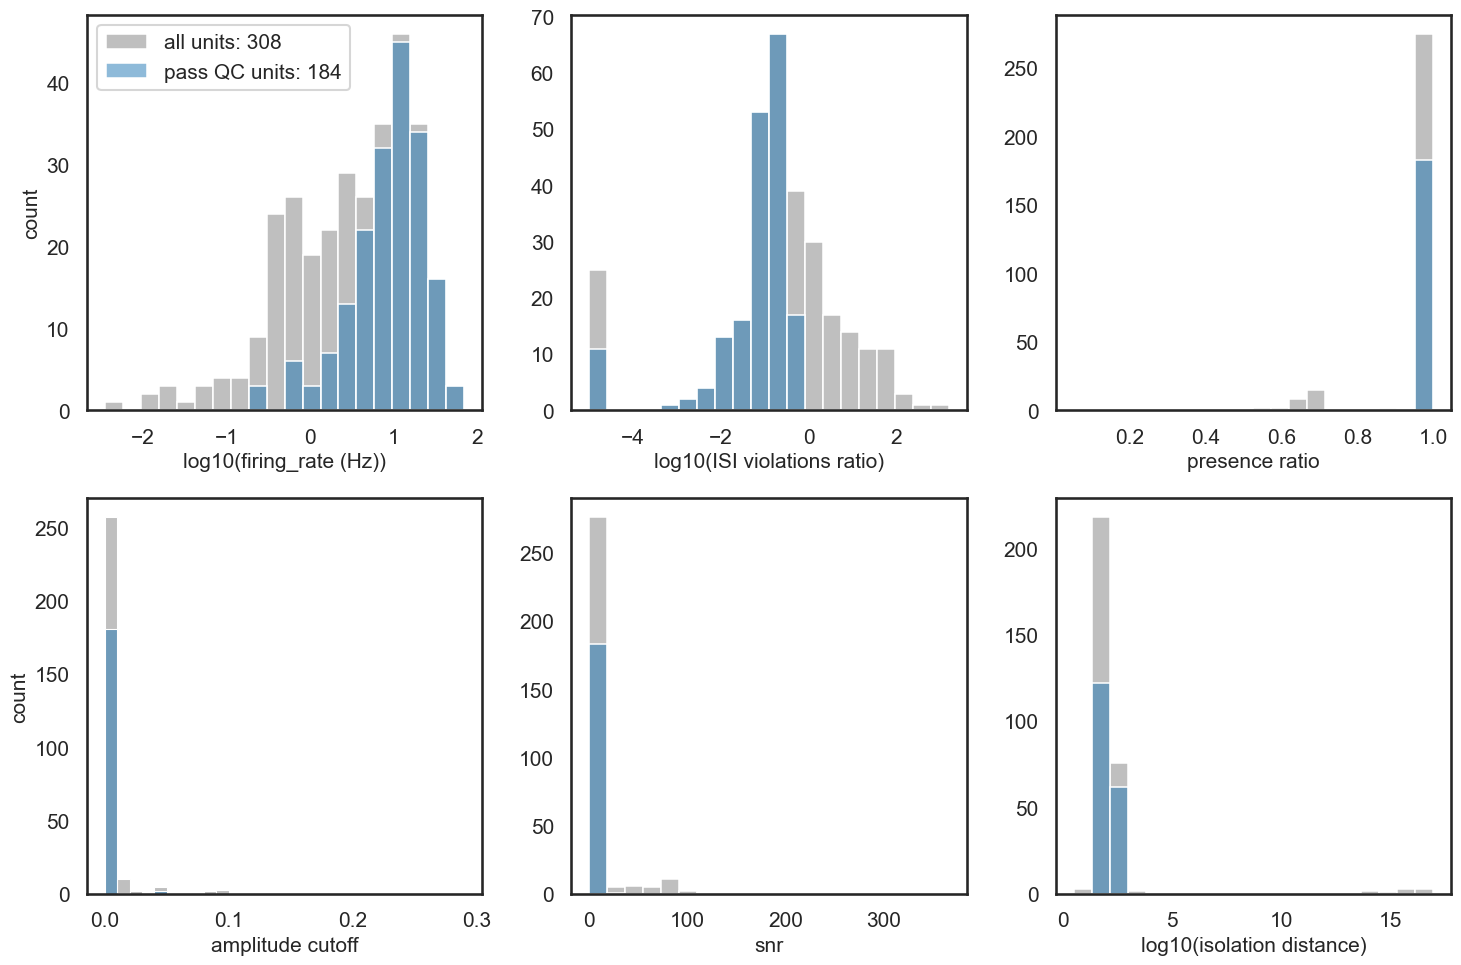

In [8]:
# in this histogram we have all units in the gray and that ovelay the units that pass the quality metrics in the green
num_of_bins = 20
font_size = 15
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# let do the firing rate histogram in the log scale
fr_log = np.log10(cluster_info['firing_rate'])
bins_fr = np.histogram_bin_edges(fr_log, bins=num_of_bins)
sns.histplot(fr_log, bins=bins_fr, color='gray', ax=ax[0, 0], edgecolor=None, alpha=0.5)
sns.histplot(fr_log[cluster_info['quality']], bins=bins_fr, ax=ax[0, 0], edgecolor=None, alpha=0.5)
ax[0, 0].set_xlabel('log10(firing_rate (Hz))', fontsize=font_size)

# let do the isi_violations_ratio histogram
ISI_vio_log = np.log10(cluster_info['isi_violations_ratio']+10**-5)
bins_ISI_vio = np.histogram_bin_edges(ISI_vio_log, bins=num_of_bins)
sns.histplot(ISI_vio_log, bins=bins_ISI_vio, color='gray', ax=ax[0, 1], edgecolor=None, alpha=0.5)
sns.histplot(ISI_vio_log[cluster_info['quality']], bins=bins_ISI_vio, ax=ax[0, 1], edgecolor=None, alpha=0.5)
ax[0, 1].set_xlabel('log10(ISI violations ratio)', fontsize=font_size)

# let do the presence_ratio histogram
present_ratio = cluster_info['presence_ratio']
bins_present_ratio = np.histogram_bin_edges(present_ratio, bins=num_of_bins)
sns.histplot(present_ratio, bins=bins_present_ratio, color='gray', ax=ax[0, 2], edgecolor=None, alpha=0.5)
sns.histplot(present_ratio[cluster_info['quality']], bins=bins_present_ratio, ax=ax[0, 2], edgecolor=None, alpha=0.5)
ax[0, 2].set_xlabel('presence ratio', fontsize=font_size)

# let do the amplitude_cutoff histogram
amplitude_cutoff = cluster_info['amplitude_cutoff']
bins_amplitude_cutoff = np.arange(0, .3, .01) 
sns.histplot(amplitude_cutoff, bins=bins_amplitude_cutoff, color='gray', ax=ax[1, 0], edgecolor=None, alpha=0.5)
sns.histplot(amplitude_cutoff[cluster_info['quality']], bins=bins_amplitude_cutoff, ax=ax[1, 0], edgecolor=None, alpha=0.5)
ax[1, 0].set_xlabel('amplitude cutoff', fontsize=font_size)

# let do the snr histogram
snr = cluster_info['snr']
bins_snr = np.histogram_bin_edges(snr, bins=num_of_bins)
sns.histplot(snr, bins=bins_snr, color='gray', ax=ax[1, 1], edgecolor=None, alpha=0.5)
sns.histplot(snr[cluster_info['quality']], bins=bins_snr, ax=ax[1, 1], edgecolor=None, alpha=0.5)
ax[1, 1].set_xlabel('snr', fontsize=font_size)

# let do the isolation_distance histogram
isolation_distance = np.log10(cluster_info['isolation_distance']+10**-5)
# let remove the nan values from the isolation_distance
isolation_distance = isolation_distance[~np.isnan(isolation_distance)]
bins_isolation_distance = np.histogram_bin_edges(isolation_distance, bins=num_of_bins)
sns.histplot(isolation_distance, bins=bins_isolation_distance, color='gray', ax=ax[1, 2], edgecolor=None, alpha=0.5)
sns.histplot(isolation_distance[cluster_info['quality']], bins=bins_isolation_distance, ax=ax[1, 2], edgecolor=None, alpha=0.5)
ax[1, 2].set_xlabel('log10(isolation distance)', fontsize=font_size)
# let add the legend to the plot
ax[0, 0].legend([f'all units: {len(fr_log)}', f'pass QC units: {len(fr_log[cluster_info["quality"]])}'], fontsize=font_size)

# let set the font size of the x and y labels and the ticks to the 15
for i in range(2):
    for j in range(3):
        ax[i, j].tick_params(axis='both', which='major', labelsize=15)
        # remmove the y label all the subplots
        if j != 0:
            ax[i, j].set_ylabel('')
        else:
            ax[i, j].set_ylabel('count', fontsize=font_size)
plt.tight_layout()
plt.show()

# let save the figure
fig.savefig(os.path.join(save_folder, 'quality_metrics.png'), dpi=300)
fig.savefig(os.path.join(save_folder, 'quality_metrics.pdf'), dpi=300)

Noisy channel rank (channels with >2 noisy units): [167, 283, 113, 161, 281, 328, 271]
Noisy unit count for channels: {167: 28, 283: 14, 113: 12, 161: 10, 281: 10, 328: 3, 271: 3}


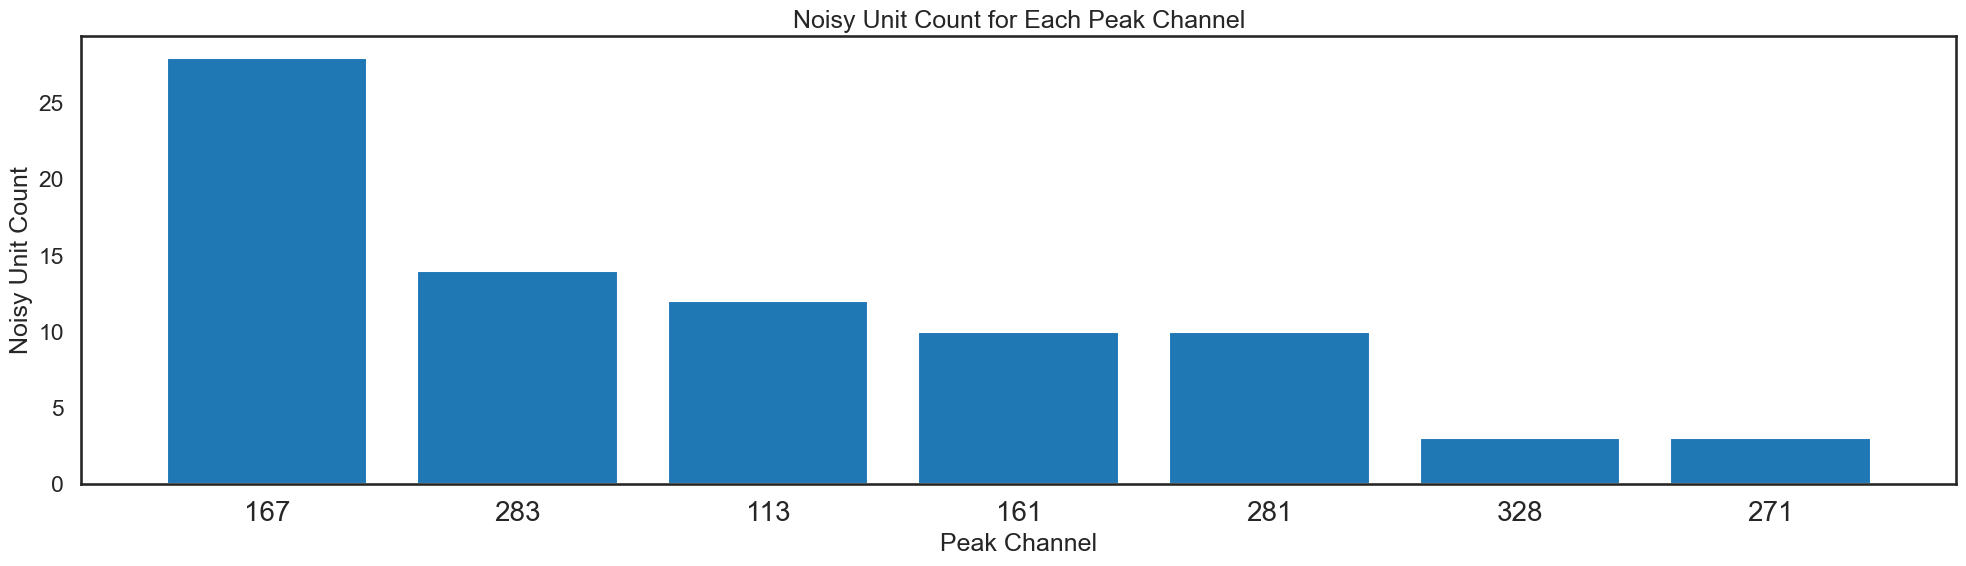

In [9]:
# Load preprocessing .json file if exists
preprocess_path = os.path.join(session_path, 'preprocessed', 'block0_imec0.ap_recording1.json')
if os.path.exists(preprocess_path):
    preprocess = json.load(open(preprocess_path))
    try:
        processed_channels = preprocess['kwargs']['channel_ids']
        processed_ids = [int(ch.split('AP')[-1]) for ch in processed_channels]
        removed_channels = sorted(set(range(384)) - set(processed_ids))
    except:
        removed_channels = []
    print(f"Removed {len(removed_channels)} channels")
    print(f"Removed channels: {removed_channels}")

# Identify potential noise channels
# noisy_units = [14, 16, 24, 28, 47, 48, 60, 61, 79, 88, 90, 96, 104, 117]
noisy_units = cluster_info[cluster_info['quality'] == False]['unit_ids'].values

# Show peak_channel for noisy units
noisy_peaks = cluster_info[cluster_info['unit_ids'].isin(noisy_units)][["unit_ids", "peak_channel"]]
peak_counts = noisy_peaks['peak_channel'].value_counts()
# Only show channels with more than 2 noisy units
filtered_peak_counts = peak_counts[peak_counts > 2]
print(f'Noisy channel rank (channels with >2 noisy units): {filtered_peak_counts.index.astype(int).tolist()}')
print(f'Noisy unit count for channels: {filtered_peak_counts.to_dict()}')

# Plot bar plot of noisy unit count for each peak_channel (fixed)
plt.figure(figsize=(20, 6))
x_positions = range(len(filtered_peak_counts))
plt.bar(x_positions, filtered_peak_counts.values)
plt.xlabel('Peak Channel')
plt.ylabel('Noisy Unit Count')
plt.title('Noisy Unit Count for Each Peak Channel')
plt.xticks(x_positions, filtered_peak_counts.index.astype(int), rotation=0, fontsize=20)
plt.tight_layout()
plt.show()

In [10]:
# Lookup units based on the peak channel
peak_channel_lookup = 286
peak_channel_unit_rows = cluster_info[cluster_info['peak_channel'] == peak_channel_lookup]
peak_channel_unit_rows[["unit_ids","default_qc","labels","manual_quality","quality","peak_channel"]]

,unit_ids,default_qc,labels,manual_quality,quality,peak_channel
303,367,False,noise,False,False,286


In [11]:
# Save the cluster_info_enhanced to the data folder as tsv file
cluster_info_enhanced = cluster_info
cluster_info_enhanced.to_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t', index=False)

# Print number of the neurons that pass the quality metrics
print(cluster_info['manual_quality'].value_counts())
print(cluster_info['quality'].value_counts())
cluster_info_enhanced.head()

manual_quality
True     184
False    124
Name: count, dtype: int64
quality
True     184
False    124
Name: count, dtype: int64


,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,firing_rate,...,velocity_below,peak_channel,segment_name,n_samples,trough_to_peak_ms,global_unit_ids,labels,default_qc,manual_quality,quality
0,0.177865,11.471684,57.062499,3.027344,2.399493,NaN,NaN,NaN,1.00,0.353317,...,NaN,206,block0_imec0.ap_recording1,210,0.100000,1,noise,False,False,False
1,0.000914,0.315654,0.163394,-48.437500,3.963820,1.540677,5.961181,1.665392,5.40,3.027069,...,NaN,4,block0_imec0.ap_recording1,210,0.466667,2,mua,True,True,True
2,0.000063,0.319724,0.135614,-39.355470,3.735208,1.525284,6.413722,1.797423,11.41,6.596701,...,NaN,96,block0_imec0.ap_recording1,210,0.700000,3,sua,True,True,True
3,0.000636,3.587925,3.830089,0.000000,1.731947,NaN,NaN,NaN,1.41,0.609841,...,NaN,126,block0_imec0.ap_recording1,210,0.566667,4,noise,True,True,True
4,0.003684,1.151130,1.327882,-12.109375,4.938778,NaN,NaN,NaN,0.80,0.265639,...,NaN,96,block0_imec0.ap_recording1,210,0.166667,5,noise,True,True,True


### Plot units on NP2 channel map

Parse the session `.imro` file, map each AP channel index to probe (x, y), then overlay selected `unit_ids` using their `peak_channel` from `cluster_info`.


In [12]:
import ast
import re
import pandas as pd

optotag_path = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412/optotag_results_all_sessions.txt'

# ---------------------------
# Choose what to load:
#   - session_selector = session_name   -> one specific session
#   - session_selector = "all"          -> all sessions
#   - session_selector = None           -> all sessions
# ---------------------------
# session_selector = session_name
session_selector = "all"

with open(optotag_path, 'r') as f:
    txt = f.read()

# Parse every session block in the file
pattern = re.compile(
    r"Session:\s*(?P<session>.+?)\s*[\r\n]+"
    r"[\s\S]*?Tagged units\s*\(unit_ids\)\s*:\s*(?P<tagged>\[[^\]]*\])"
    r"[\s\S]*?Peak channels\s*:\s*(?P<peaks>\[[^\]]*\])",
    re.MULTILINE
)

rows = []

for m in pattern.finditer(txt):
    session = m.group("session").strip()
    tagged_units = ast.literal_eval(m.group("tagged"))
    peak_channels = ast.literal_eval(m.group("peaks"))

    if len(tagged_units) != len(peak_channels):
        raise ValueError(
            f"Tagged units and peak channels length mismatch for {session}: "
            f"{len(tagged_units)} vs {len(peak_channels)}"
        )

    # Keep only the requested session unless using all sessions
    if session_selector not in [None, "all"] and session != session_selector:
        continue

    for unit_id, peak_channel in zip(tagged_units, peak_channels):
        rows.append({
            "session": session,
            "unit_ids": unit_id,
            "peak_channel": peak_channel
        })

if not rows:
    if session_selector in [None, "all"]:
        raise ValueError(f"No sessions found in {optotag_path}")
    else:
        raise ValueError(f"Could not find session '{session_selector}' in {optotag_path}")

unit_peak = pd.DataFrame(rows)
unit_peak = unit_peak.merge(
    channel_df,
    left_on='peak_channel',
    right_on='channel_id',
    how='left'
)

# Optional:
# # If you selected a single session and don't want the session column:
# if session_selector not in [None, "all"]:
#     unit_peak = unit_peak.drop(columns=["session"])

# # --- Select units and find their peak channels ---
# selected_units = [4, 203, 302]
# unit_peak = cluster_info[cluster_info['unit_ids'].isin(selected_units)][['unit_ids', 'peak_channel']].copy()
# unit_peak = unit_peak.merge(channel_df, left_on='peak_channel', right_on='channel_id', how='left')

unit_peak

,session,unit_ids,peak_channel,channel_id,shank_id,electrode_id,x,y
0,20251202-SL412-Random1_g0,129,128,128,0,80,0,600
1,20251202-SL412-Random1_g0,141,134,134,0,86,0,645
2,20251202-SL412-Random1_g0,182,141,141,0,93,32,690
3,20251202-SL412-Random1_g0,197,51,51,3,99,782,735
4,20251202-SL412-Random1_g0,206,145,145,1,49,282,360
...,...,...,...,...,...,...,...,...
235,20251218-SL412-Punish6_g0,261,353,353,3,65,782,480
236,20251218-SL412-Punish6_g0,275,353,353,3,65,782,480
237,20251218-SL412-Punish6_g0,279,186,186,1,90,250,675
238,20251218-SL412-Punish6_g0,284,201,201,0,105,32,780


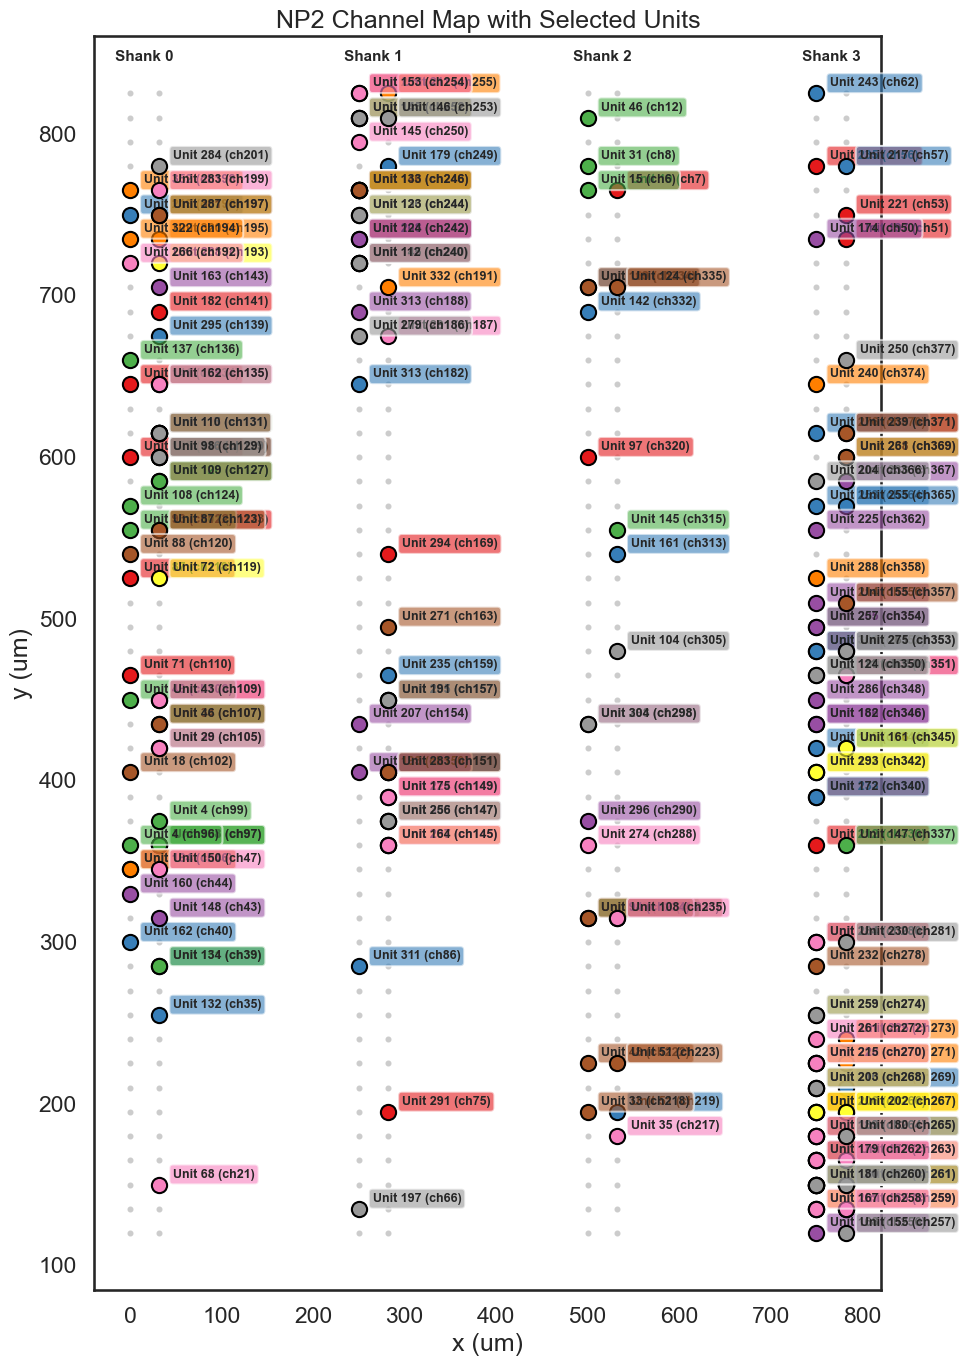

In [13]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14))

for shank_id, grp in channel_df.groupby('shank_id'):
    ax.scatter(grp['x'], grp['y'], s=8, c='#ccc', zorder=1)

cmap = plt.cm.Set1
for i, (_, row) in enumerate(unit_peak.iterrows()):
    color = cmap(i / max(len(unit_peak) - 1, 1))
    ax.scatter(row['x'], row['y'], s=120, c=[color], edgecolors='k',
               linewidths=1.5, zorder=3)
    ax.annotate(f"Unit {int(row['unit_ids'])} (ch{int(row['peak_channel'])})",
                (row['x'], row['y']), fontsize=9, fontweight='bold',
                xytext=(10, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc=color, alpha=0.6))

for sid in sorted(channel_df['shank_id'].unique()):
    cx = sid * NP2_SHANK_PITCH + NP2_COL_PITCH / 2
    ax.text(cx, channel_df['y'].max() + 20, f'Shank {sid}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_title('NP2 Channel Map with Selected Units')
plt.tight_layout()
plt.show()

# print(unit_peak[['unit_ids', 'peak_channel', 'shank_id', 'electrode_id', 'x', 'y']])
# Save figure as pdf
results_folder = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412'
fig.savefig(os.path.join(results_folder, 'optotag_channel_map.pdf'), dpi=300)


## Optotag

### Load spike data

In [14]:
# Setup Fs
apFs = 30000
behaviorFs = 10000
cameraFs = 50

# Load spike data
spike_times = np.load(os.path.join(spike_path, 'spike_times.npy'), allow_pickle=True).flatten()
spike_clusters = np.load(os.path.join(spike_path, 'spike_clusters.npy'), allow_pickle=True).flatten()
segment_index = np.zeros_like(spike_times)  # Always 0
spikes = np.stack([spike_times, spike_clusters, segment_index], axis=1)
print(f'Converted spikes shape: {spikes.shape}')
print(f'First 5 spikes:\n{spikes[:5]}')

# Extract good units
cluster_info_enhanced = pd.read_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t')
good_units = cluster_info_enhanced[cluster_info_enhanced['quality']]['global_unit_ids'].values
good_unit_ids = cluster_info_enhanced[cluster_info_enhanced['quality']]['unit_ids'].values
print(f'Number of good units: {len(good_units)}')

cluster_info_enhanced[["unit_ids","global_unit_ids","default_qc","manual_quality","quality","peak_channel"]].head()

Converted spikes shape: (5743378, 3)
First 5 spikes:
[[  0 295   0]
 [  0 126   0]
 [  1 237   0]
 [  1  35   0]
 [  1 156   0]]
Number of good units: 184


,unit_ids,global_unit_ids,default_qc,manual_quality,quality,peak_channel
0,2,1,False,False,False,206
1,3,2,True,True,True,4
2,4,3,True,True,True,96
3,5,4,True,True,True,126
4,6,5,True,True,True,96


### Load behavior & photometry data

In [15]:
# Load sync_*.mat
sync_times = ndap.load_mat(os.path.join(session_path, rf'sync_{session_name}.mat'))
params = ndap.convert_params_from_mat(sync_times)

# Load behavior data
data_mat = ndap.load_mat(os.path.join(session_path, rf'data_{session_name}.mat'))
water = data_mat['rightSolenoid'].flatten() if 'rightSolenoid' in data_mat else None
lick = data_mat['rightLick'].flatten() if 'rightLick' in data_mat else None
tone = data_mat['leftTone'].flatten() if 'leftTone' in data_mat else None
blueLaser = data_mat['blueLaser'].flatten() if 'blueLaser' in data_mat else None
redLaser = data_mat['redLaser'].flatten() if 'redLaser' in data_mat else None
airpuff = data_mat['airpuff'].flatten() if 'airpuff' in data_mat else None
# Extract onset times for continuous events (water, tone, lick) - all rising edges
water_onsets = ndap.get_onset_times(water, edge='rising', fs=behaviorFs, min_separation=0.5)
tone_onsets = ndap.get_onset_times(tone, edge='rising', fs=behaviorFs, min_separation=0.5)
lick_onsets = ndap.get_onset_times(lick, edge='rising', fs=behaviorFs, min_separation=0.05)
airpuff_onsets = ndap.get_onset_times(airpuff, edge='rising', fs=behaviorFs, min_separation=0.5)

# Extract onset times for laser events (filtered by >=500ms separation)
blueLaser_onsets = ndap.get_onset_times(blueLaser, fs=behaviorFs, min_separation=0.5, edge='falling')
redLaser_onsets = ndap.get_onset_times(redLaser, fs=behaviorFs, min_separation=1, edge='falling')
tone_only_onsets, opto_only_onsets, pair_onsets, _, _ = ndap.split_paired_events(
    event1_onsets=tone_onsets,
    event2_onsets=redLaser_onsets,
    pair_tolerance=0.05
)

# Extract rewarded lick (i.e. first lick after water delivery)
if water_onsets.size == 0 or lick_onsets.size == 0:
    print('No water or lick onsets found')
    water_lick_onsets = np.array([])
else:
    # searchsorted assumes right_lick_on is sorted ascending
    if np.any(np.diff(lick_onsets) < 0):
        lick_onsets_sorted = np.sort(lick_onsets)
    else:
        lick_onsets_sorted = lick_onsets
    pos = np.searchsorted(lick_onsets_sorted, water_onsets, side="left")
    valid = pos < lick_onsets_sorted.size
    water_lick_onsets = lick_onsets_sorted[pos[valid]]
water_lick_onsets = np.unique(water_lick_onsets)


# ------------------------------------------------------------------
# Session-specific event modification
#   For random1, redLaser_onsets is 500ms earlier than calculation
# ------------------------------------------------------------------
if 'RANDOM1' in session_name.upper():
    redLaser_onsets = redLaser_onsets - 0.5*behaviorFs


# ------------------------------------------------------------------
# Session-specific opto event selection  (notebook: Plot PSTH near blue opto)
#   event = blueLaser_onsets        # for random1-3
#   event = blueLaser_onsets[:50]   # for reward1 and after
#   event = blueLaser_onsets[-50:]  # for random4
# ------------------------------------------------------------------
session_upper = session_name.upper()
if 'RANDOM1' in session_upper or 'RANDOM2' in session_upper or 'RANDOM3' in session_upper:
    optotag_onsets = blueLaser_onsets           # for random1-3
elif 'RANDOM4' in session_upper:
    optotag_onsets = blueLaser_onsets[-50:]     # for random4
else:
    optotag_onsets = blueLaser_onsets[:50]      # for reward1 and after
print(f'  Using {len(optotag_onsets)} opto optotag_events for SALT (rule: '
        f'{"all" if optotag_onsets is blueLaser_onsets else ("last 50" if "RANDOM4" in session_upper else "first 50")})')


# Finialize events
if 'RANDOM' in session_name.upper():
        event_types = [water_lick_onsets, tone_onsets, airpuff_onsets, redLaser_onsets, optotag_onsets]
        event_names = ['water_lick', 'tone', 'airpuff', 'red_opto', 'blue_opto']
else:
    event_types = [opto_only_onsets, tone_only_onsets, pair_onsets, water_lick_onsets, airpuff_onsets, optotag_onsets]
    event_names = ['opto_only', 'tone_only', 'pair', 'water_lick', 'airpuff', 'blue_opto']


# Load photometry data
timeseries_mat = ndap.load_mat(os.path.join(session_path, rf'timeseries_{session_name}.mat'))
# Extract DA photometry
DA = timeseries_mat['timeSeries']['data'][timeseries_mat['timeSeries']['name'].index('dLight')]
photometryFs = timeseries_mat['timeSeries']['finalFs'][timeseries_mat['timeSeries']['name'].index('dLight')].item()


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


  Using 52 opto optotag_events for SALT (rule: all)


In [16]:
# Show photometry trace
# plt.plot(DA[:int(50*photometryFs)])
# plt.show()

### Read from h5

In [17]:
import h5py

h5_path = save_folder + f'/analysis-{session_name}.h5'

def _decode_if_needed(x):
    if isinstance(x, bytes):
        return x.decode('utf-8')
    if isinstance(x, np.ndarray) and x.dtype.kind == 'S':
        return x.astype(str)
    if isinstance(x, np.ndarray) and x.dtype == object:
        return np.array([
            i.decode('utf-8') if isinstance(i, bytes) else i
            for i in x
        ], dtype=object)
    return x

def load_h5_item(item):
    """Recursively load an h5py Group or Dataset into Python objects."""
    if isinstance(item, h5py.Dataset):
        value = item[()]

        # Convert numpy scalar to Python scalar when possible
        if isinstance(value, np.generic):
            value = value.item()

        return _decode_if_needed(value)

    elif isinstance(item, h5py.Group):
        return {key: load_h5_item(item[key]) for key in item.keys()}

    else:
        raise TypeError(f'Unsupported HDF5 item type: {type(item)}')

# Load entire h5 file into a nested dict
with h5py.File(h5_path, 'r') as h5_file:
    analysis = {key: load_h5_item(h5_file[key]) for key in h5_file.keys()}

# Show top-level keys
print(analysis.keys())


dict_keys(['event_times', 'licks_airpuff', 'licks_red_opto', 'licks_tone', 'licks_water_lick', 'metadata', 'salt_results', 'spikes_airpuff', 'spikes_blue_opto', 'spikes_red_opto', 'spikes_tone', 'spikes_water_lick', 'trials_airpuff', 'trials_licks_airpuff', 'trials_licks_red_opto', 'trials_licks_tone', 'trials_licks_water_lick', 'trials_red_opto', 'trials_spikes_airpuff', 'trials_spikes_red_opto', 'trials_spikes_tone', 'trials_spikes_water_lick', 'trials_tone', 'trials_water_lick', 'unit_info'])


### Plot PSTH near blue opto


In [18]:
event = optotag_onsets
# event = blueLaser_onsets[:50] # for reward1 and after
# event = blueLaser_onsets[-50:] # for random4

event_label = 'blue opto'
bin_size_ms = 5             # in ms
time_range = (-0.05,0.1)    # in sec
event_color = 'tab:cyan'
event_duration = 0.01        # in sec

# Run salt to find optotagged units
salt_results = ndap.run_salt(
    spikes, event,
    test_window=0.02,
    bin_size=0.001,
    baseline_duration=1.0,
    same_system=False, params=params,
    include_units=good_units,
    unit_ids=good_unit_ids,
    expected_direction='excite',
    reliability_threshold=0.25,  # optional: fires on ≥25% of trials
)
tagged_units = salt_results['unit_ids'][salt_results['tagged']]
print(f"Tagged units: {tagged_units}")

# Print rows of optotagged units (show unit_ids, global_unit_ids, peak_channel, default_qc, manual_quality, quality)
# cols_to_show = ['unit_ids', 'global_unit_ids', 'peak_channel', 'quality']
# print(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), cols_to_show])

# Print the range of peak_channel for the optotagged units
print(f"Peak channel range for optotagged units: {np.min(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])} to {np.max(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])}")

# Plot PSTH of blue opto
# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)


Extracting baseline spike trains...
Extracting test spike trains...


Running SALT: 100%|██████████| 184/184 [00:00<00:00, 687.02it/s]

SALT complete: 89/184 units significant (p <= 0.01), 24 tagged after filters (direction='excite', latency>=2ms, reliability>=25%)
Tagged units: [120 129 141 182 192 197 206 208 212 224 229 231 233 235 236 256 261 265
 291 294 299 330 359 364]
Peak channel range for optotagged units: 51 to 371


### Plot PSTH of red opto

In [19]:
# Plot PSTH aligned to red stim
event = redLaser_onsets
event_label = 'red opto'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:red'
event_duration = 0.5        # in sec

# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)

### Plot PSTH of water events

In [20]:
# Plot PSTH aligned to water
event = water_lick_onsets
event_label = 'water'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:cyan'
event_duration = 0.2        # in sec

# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)

### Plot PSTH of airpuff

In [21]:
# Plot PSTH aligned to airpuff
event = airpuff_onsets
event_label = 'water'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:gray'
event_duration = 0.2        # in sec

# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)

### Plot response changes during event period across trials

In [ ]:
# Align spikes to a chosen event and count spikes from 0 to 1 s after onset
# Change `event_times` / `event_name` here to reuse this block for another event.
event_times = opto_only_onsets
event_name = 'red opto'
bin_size_ms = 5
time_range = (-1, 2)
response_window_ms = (0, 1000)
xaxis = ndap.get_time_axis(time_range=time_range, bin_size_ms=bin_size_ms)

# Align good units to the selected event
event_aligned = ndap.get_spikes(
    spikes,
    event_times,
    time_range=time_range,
    bin_size_ms=bin_size_ms,
    same_system=False,
    params=params,
    include_units=good_units,
)
response_counts = ndap.get_window(
    event_aligned['count'],
    onset_time=0,
    window_ms=response_window_ms,
    xaxis=xaxis,
    bin_size_ms=bin_size_ms,
)

# Number of spikes in the 0-1 s window for each trial and each unit
n_grouped_trials = 5
event_counts = response_counts.sum(axis=2)  # shape: (n_units, n_events)
event_rates = event_counts / (response_window_ms[1] - response_window_ms[0])
event_rates_diff_grouped = ndap.get_trial_changes(event_rates, n_grouped_trials=n_grouped_trials, n_baseline_trials=5)

# Calculate slope of event_rates_diff_grouped vs trial
event_rates_slopes = (event_rates_diff_grouped[:, -1] - event_rates_diff_grouped[:, 0]) / (
    (event_rates_diff_grouped.shape[1] - 1) * n_grouped_trials
)


In [32]:
# Compute per-unit modulation index for the same event using the aligned spikes above
baseline_window_ms = (-1000, 0)
response_window_ms = (0, 1000)

mod_results = ndap.get_event_modulation(
    event_aligned,
    baseline_window=baseline_window_ms,
    response_window=response_window_ms,
    mod_type='norm',
    test='wilcoxon',
    alpha=0.05,
)

mod_index_diff_grouped = ndap.get_trial_changes(mod_results['mod_index_per_trial'], n_grouped_trials=n_grouped_trials, n_baseline_trials=5)
if mod_index_diff_grouped.ndim != 2 or mod_index_diff_grouped.shape[1] < 2:
    mod_index_slopes = np.full(mod_index_diff_grouped.shape[0], np.nan, dtype=float)
else:
    mod_index_slopes = (mod_index_diff_grouped[:, -1] - mod_index_diff_grouped[:, 0]) / (
        (mod_index_diff_grouped.shape[1] - 1) * n_grouped_trials
    )

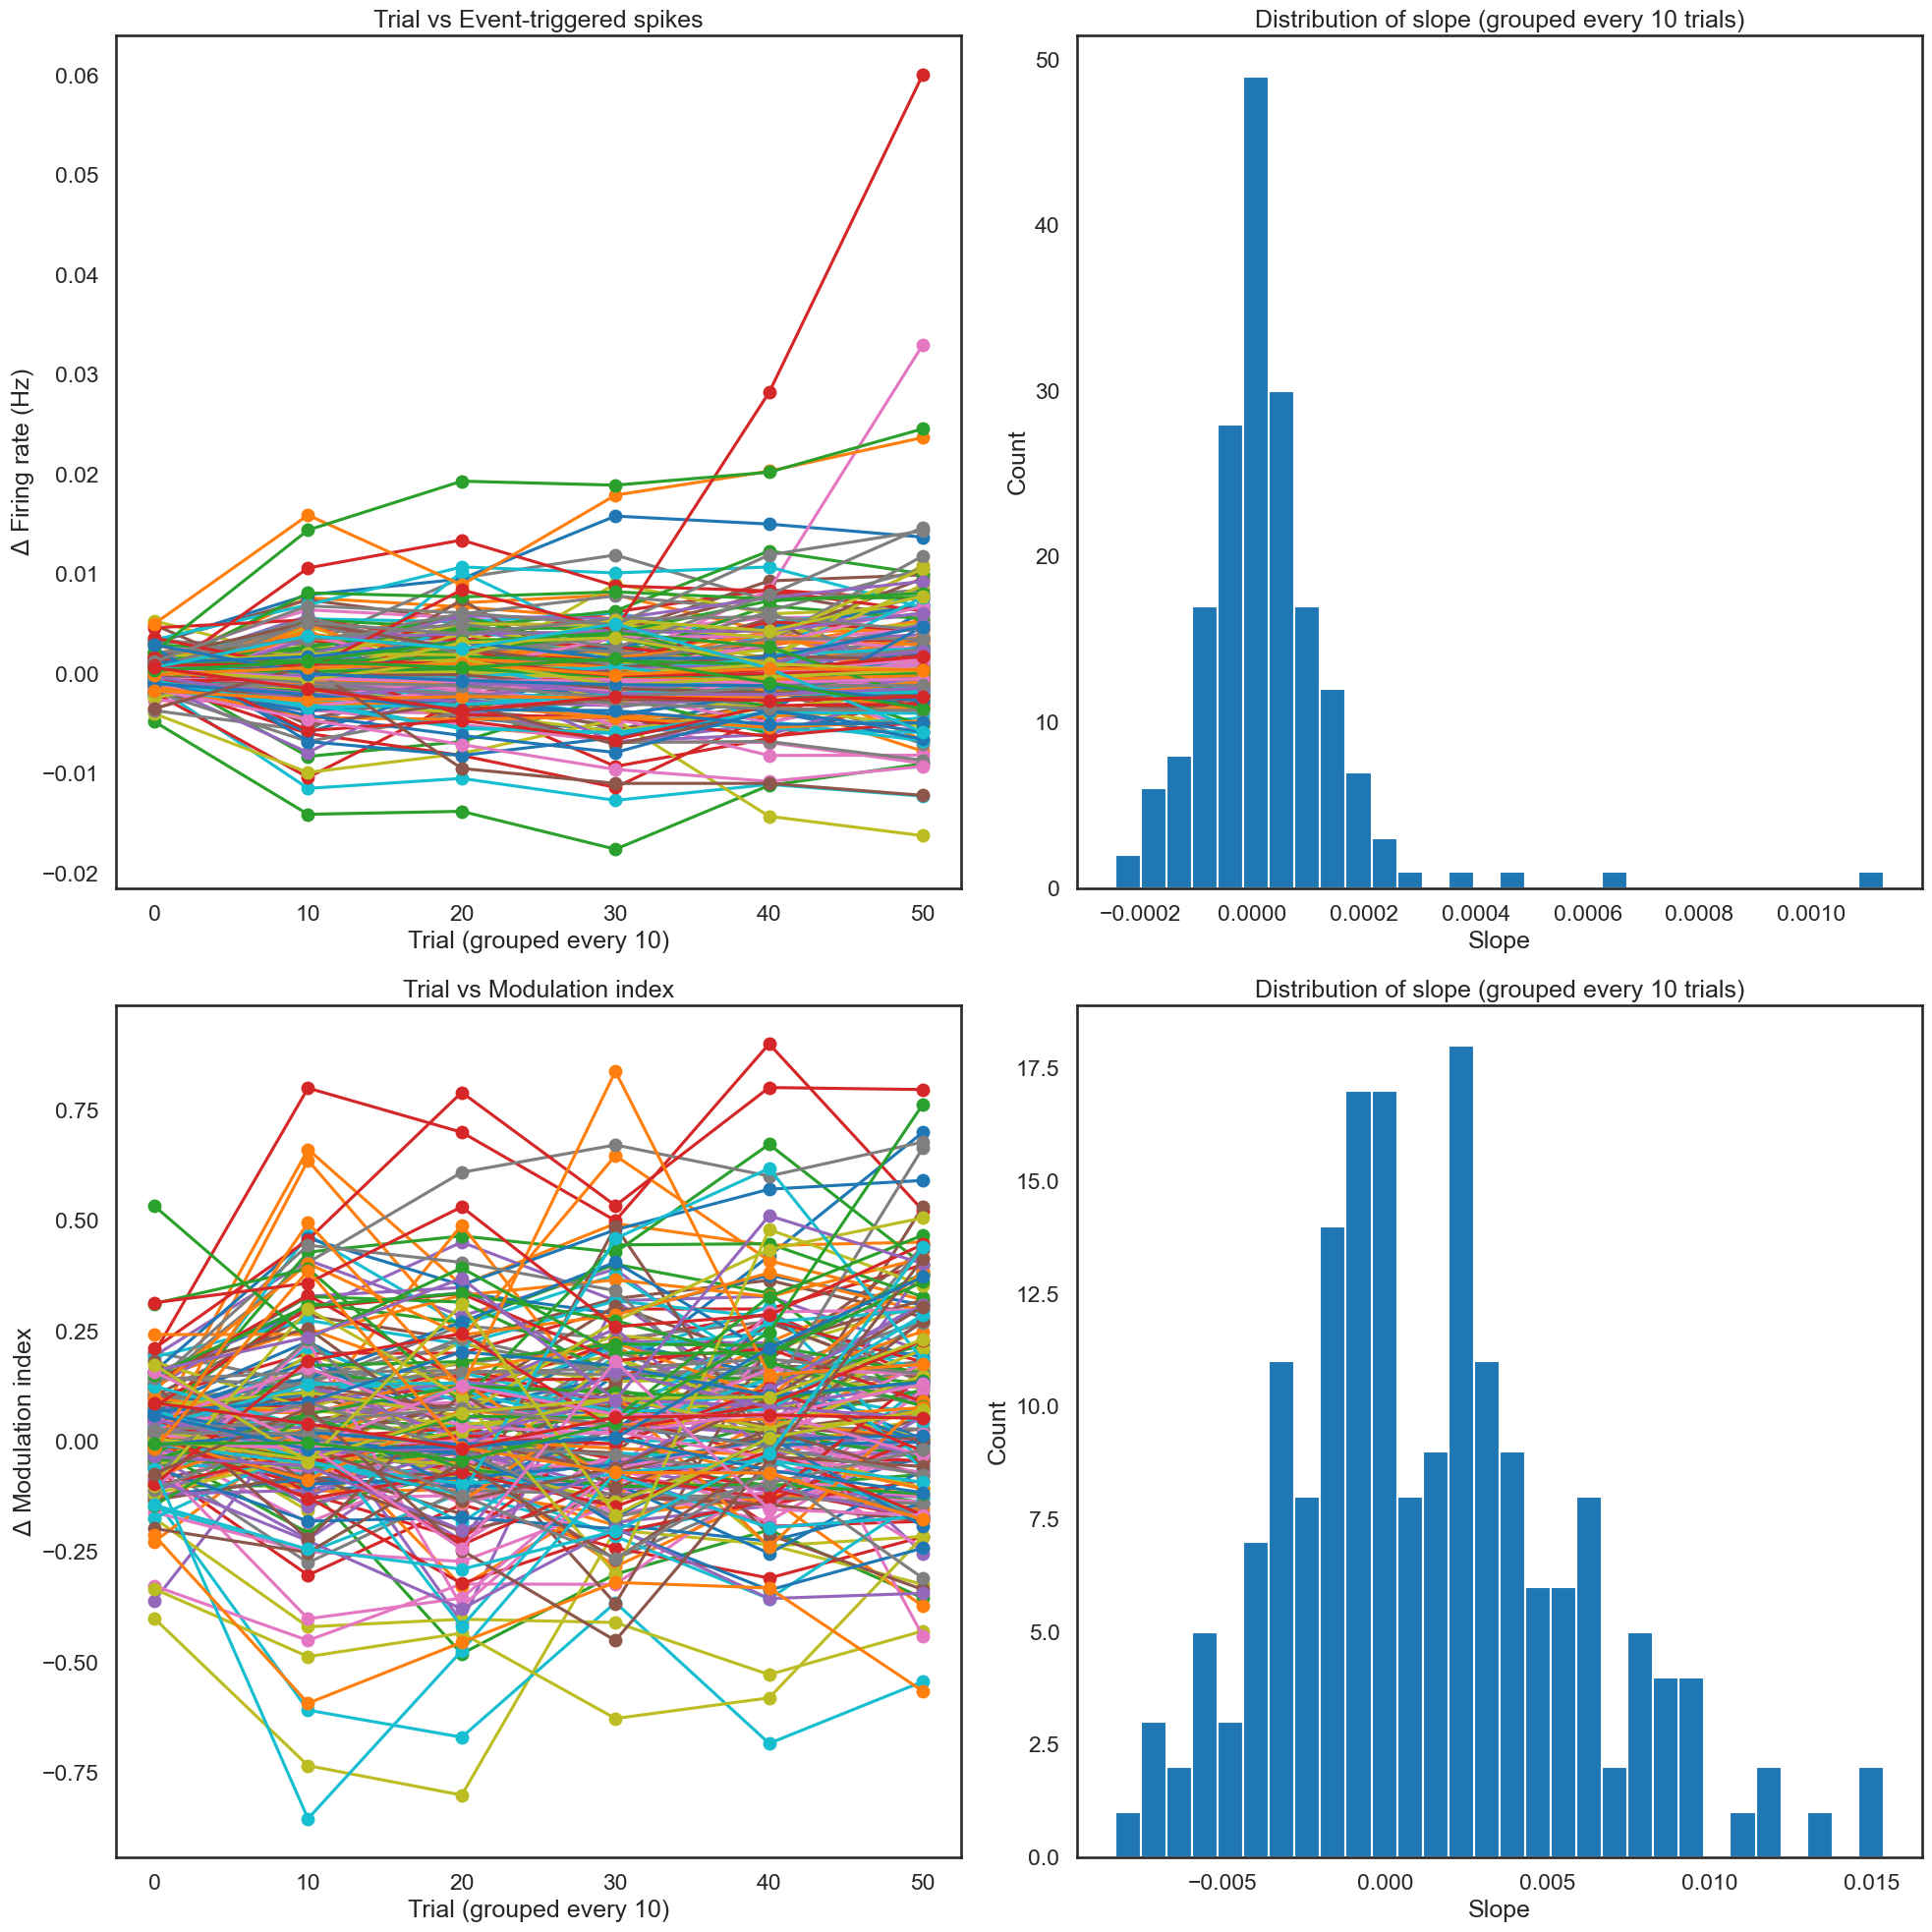

In [ ]:
# Plot trial vs normalized spikes for each unit, with x-axis as individual trial
fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Plot grouped event rates (averaged every n_grouped_trials)
for i, unit_id in enumerate(good_unit_ids):
    axs[0,0].plot(
        np.arange(event_rates_diff_grouped.shape[1]) * n_grouped_trials,
        event_rates_diff_grouped[i],
        marker='o',
    )
axs[0,0].set_xlabel(f'Trial (grouped every {n_grouped_trials})')
axs[0,0].set_ylabel(r'$\Delta$ Firing rate (Hz)')
axs[0,0].set_title(f'Trial vs Event-triggered spikes')

# Plot distribution of slope (event_rates_diff_grouped vs trial)
axs[0,1].hist(event_rates_slopes, bins=30)
axs[0,1].set_xlabel('Slope')
axs[0,1].set_ylabel('Count')
axs[0,1].set_title(f'Distribution of slope (grouped every {n_grouped_trials} trials)')



# Plot grouped event rates (averaged every n_grouped_trials)
for i, unit_id in enumerate(good_unit_ids):
    axs[1,0].plot(
        np.arange(mod_index_diff_grouped.shape[1]) * n_grouped_trials,
        mod_index_diff_grouped[i],
        marker='o',
    )
axs[1,0].set_xlabel(f'Trial (grouped every {n_grouped_trials})')
axs[1,0].set_ylabel(r'$\Delta$ Modulation index')
axs[1,0].set_title(f'Trial vs Modulation index')

# Plot distribution of slope (event_rates_diff_grouped vs trial)
axs[1,1].hist(mod_index_slopes, bins=30)
axs[1,1].set_xlabel('Slope')
axs[1,1].set_ylabel('Count')
axs[1,1].set_title(f'Distribution of slope (grouped every {n_grouped_trials} trials)')

plt.tight_layout()
plt.show()

### Plot lick raster plot for all events

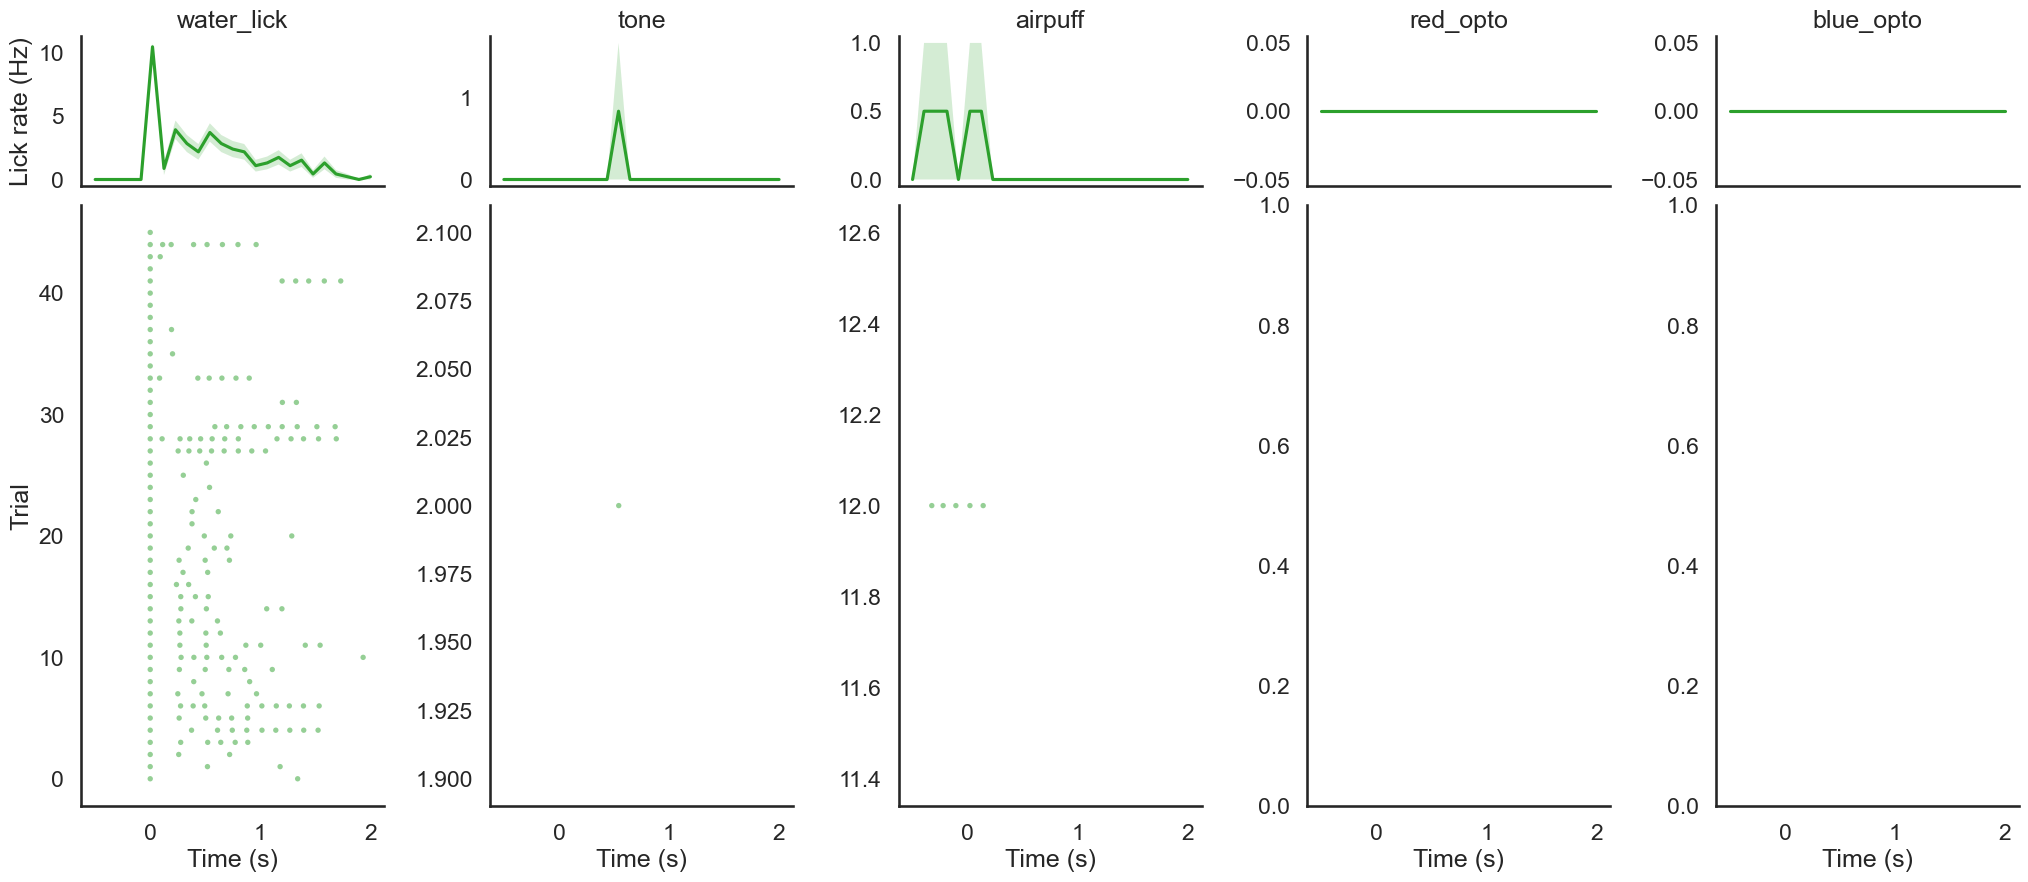

In [25]:
n_events_plot = len(event_types)
fig = plt.figure(figsize=(5 * n_events_plot, 10))
outer_gs = fig.add_gridspec(1, n_events_plot, wspace=0.35)

for col, (event_times, event_name) in enumerate(zip(event_types, event_names)):
    lick_aligned = ndap.get_licks(lick_onsets, event_times, time_range=(-0.5, 2), bin_size_ms=100)

    inner_gs = outer_gs[col].subgridspec(2, 1, height_ratios=[1, 4], hspace=0.05)
    ax_rate   = fig.add_subplot(inner_gs[0])
    ax_raster = fig.add_subplot(inner_gs[1], sharex=ax_rate)

    ndap.plot_sem(lick_aligned['rate'], lick_aligned['xaxis'],
                    plot_individual=False, color='tab:green', ax=ax_rate)
    ax_rate.set_ylabel('Lick rate (Hz)' if col == 0 else '')
    ax_rate.set_title(event_name)
    ax_rate.tick_params(axis='x', labelbottom=False)
    ax_rate.spines['top'].set_visible(False)
    ax_rate.spines['right'].set_visible(False)

    ndap.plot_raster(lick_aligned['times'], lick_aligned['xaxis'],
                        color='tab:green', ax=ax_raster)
    ax_raster.set_xlabel('Time (s)')
    ax_raster.set_ylabel('Trial' if col == 0 else '')
    ax_raster.spines['top'].set_visible(False)
    ax_raster.spines['right'].set_visible(False)

In [33]:
bin_size_ms = 100
time_range = (-1, 2)
response_window_ms = (0, 1000)
xaxis = ndap.get_time_axis(time_range=time_range, bin_size_ms=bin_size_ms)

lick_aligned = ndap.get_licks(lick_onsets, water_lick_onsets, time_range=time_range, bin_size_ms=bin_size_ms)
# Add new dimension to lick_aligned
lick_aligned['count'] = lick_aligned['count'][np.newaxis, :, :]
lick_aligned['rate'] = lick_aligned['rate'][np.newaxis, :, :]

Text(0.5, 1.0, 'Distribution of modulation index')

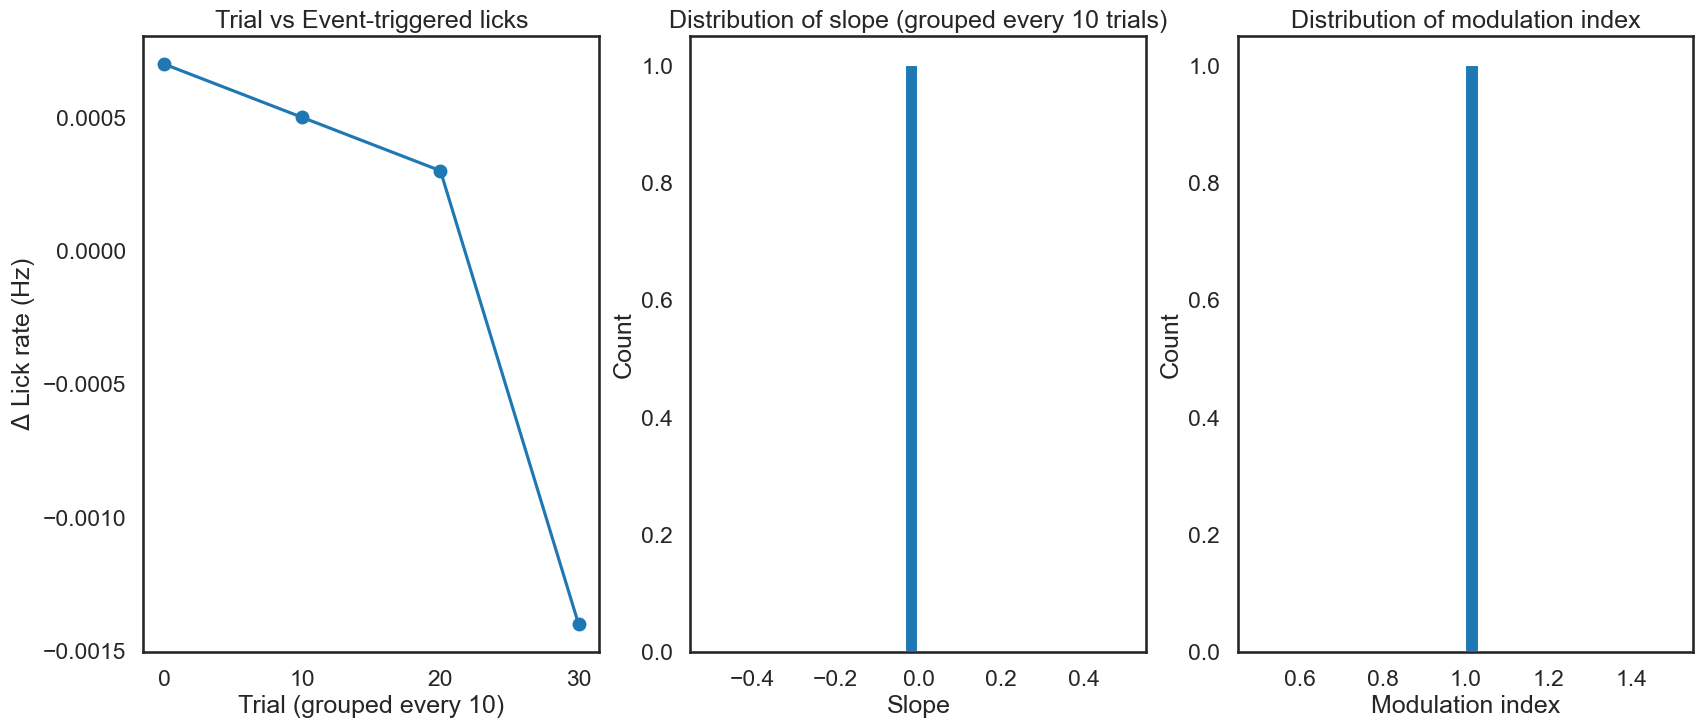

In [38]:
lick_responses = ndap.get_window(
    lick_aligned['count'],
    onset_time=0,
    window_ms=response_window_ms,
    xaxis=xaxis,
    bin_size_ms=bin_size_ms,
)

# Number of spikes in the 0-1 s window for each trial and each unit
lick_counts = lick_responses.sum(axis=2)  # shape: (n_units, n_events)
lick_rates = lick_counts / (response_window_ms[1] - response_window_ms[0])
# Center to the average of the first five trials for each unit
lick_rates_diff = lick_rates - np.mean(lick_rates[:, :5], axis=1, keepdims=True)

# Calculate average event rate for each unit every n_grouped_trials (e.g. 5)
grouped_rates = []
for unit_rates in lick_rates_diff:
    unit_group_means = []
    n_events = len(unit_rates)

    for start in range(0, n_events, n_grouped_trials):
        end = start + n_grouped_trials
        # If this is the last full group and there are leftover trials after it,
        # merge the leftovers into this final group
        if end >= n_events or (n_events - end) < n_grouped_trials:
            unit_group_means.append(unit_rates[start:].mean())
            break
        else:
            unit_group_means.append(unit_rates[start:end].mean())

    grouped_rates.append(unit_group_means)
lick_rates_diff_grouped = np.array(grouped_rates)

# Calculate slope of lick_rates_diff_grouped vs trial.
# If there is only one grouped timepoint, slope is undefined; keep as NaN.
if lick_rates_diff_grouped.ndim != 2 or lick_rates_diff_grouped.shape[1] < 2:
    slopes = np.full(lick_rates_diff_grouped.shape[0], np.nan, dtype=float)
else:
    slopes = (lick_rates_diff_grouped[:, -1] - lick_rates_diff_grouped[:, 0]) / (
        (lick_rates_diff_grouped.shape[1] - 1) * n_grouped_trials
    )

# Compute per-unit modulation index for the same event using the aligned spikes above
baseline_window_ms = (-1000, 0)
response_window_ms = (0, 1000)

mod_results = ndap.get_event_modulation(
    lick_aligned,
    baseline_window=baseline_window_ms,
    response_window=response_window_ms,
    mod_type='norm',
    test='wilcoxon',
    alpha=0.05,
)

# Plot trial responses like the same for spikes
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# Plot grouped event rates (averaged every n_grouped_trials)
axs[0].plot(
    np.arange(lick_rates_diff_grouped.shape[1]) * n_grouped_trials,
    lick_rates_diff_grouped[0],
    marker='o',
)
axs[0].set_xlabel(f'Trial (grouped every {n_grouped_trials})')
axs[0].set_ylabel(r'$\Delta$ Lick rate (Hz)')
axs[0].set_title(f'Trial vs Event-triggered licks')

# Plot distribution of slope (lick_rates_diff_grouped vs trial)
finite_slopes = slopes[np.isfinite(slopes)]
if finite_slopes.size > 0:
    axs[1].hist(finite_slopes, bins=30)
else:
    axs[1].text(0.5, 0.5, 'No finite slopes', ha='center', va='center', transform=axs[1].transAxes)
axs[1].set_xlabel('Slope')
axs[1].set_ylabel('Count')
axs[1].set_title(f'Distribution of slope (grouped every {n_grouped_trials} trials)')

# Plot distribution of modulation index
mod_index = np.asarray(mod_results['mod_index'])
finite_mod_index = mod_index[np.isfinite(mod_index)]
if finite_mod_index.size > 0:
    axs[2].hist(finite_mod_index, bins=30)
else:
    axs[2].text(0.5, 0.5, 'No finite modulation indices', ha='center', va='center', transform=axs[2].transAxes)
axs[2].set_xlabel('Modulation index')
axs[2].set_ylabel('Count')
axs[2].set_title(f'Distribution of modulation index')

## Load LFP of the session

In [ ]:
from hdmf_zarr.nwb import NWBZarrIO

# If your store does not have consolidated metadata, use mode="r-"
# (read-only without requiring consolidated metadata)
with NWBZarrIO(nwb_path, mode="r") as io:
    nwbfile = io.read()

    # LFP is typically stored under processing/ecephys/LFP in these files
    ecephys = nwbfile.processing["ecephys"]
    lfp_iface = ecephys["LFP"]

    print("Available LFP ElectricalSeries:", list(lfp_iface.electrical_series.keys()))
    es_name = list(lfp_iface.electrical_series.keys())[0]  # choose the right one
    lfp_es = lfp_iface.electrical_series[es_name]

    lfp = lfp_es.data          # lazy; slicing reads only the requested chunk
    lfp_timestamp = lfp_es.timestamps      # usually present; also lazy
    lfp_timestamp = np.asarray(lfp_timestamp, float)

# Map LFP timestamp to timeNI
half_sample_shift = float(lfp_timestamp[0])
timeLFP = (lfp_timestamp - half_sample_shift) + float(params['sync']['timeImec'][0])
# Add timeLFP to params['sync']
params['sync']['timeLFP'] = timeLFP
params['sync']['lfpFs'] = int(lfp_timestamp.shape[0] / (timeLFP[-1] - timeLFP[0]))

print("LFP shape:", lfp.shape)
print("LFP timestamp shape:", timeLFP.shape)
print("LFP sampling rate:", params['sync']['lfpFs'])

PathNotFoundError: nothing found at path ''

### Align LFP to red stim

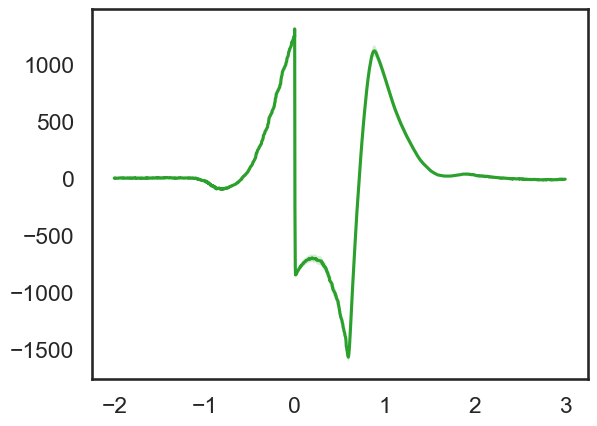

In [ ]:
chan = 0
traces, ts = ndap.get_traces(lfp[:,chan], redLaser_onsets, time_range=(-2, 3),
                            same_system=False, params=params, signal_system="lfp")

ndap.plot_sem(traces, ts, plot_individual=False, color='tab:green')

In [ ]:
cluster_info_enhanced.head()

,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,firing_rate,...,velocity_below,peak_channel,segment_name,n_samples,trough_to_peak_ms,global_unit_ids,labels,default_qc,manual_quality,quality
0,0.010777,0.301269,1.125538,-63.574220,2.997546,NaN,NaN,NaN,1.60,0.651072,...,NaN,18,block0_imec0.ap_recording1,210,0.200000,1,mua,False,True,False
1,0.000429,0.357062,0.997042,-54.492188,3.014356,1.516902,6.716370,0.924027,2.80,2.422723,...,NaN,20,block0_imec0.ap_recording1,210,0.700000,2,mua,True,True,True
2,0.000222,0.312364,0.111799,-57.519530,2.264735,0.343113,2.189102,0.515268,6.60,5.599048,...,NaN,67,block0_imec0.ap_recording1,210,0.700000,3,mua,True,True,True
3,0.000220,0.267902,0.107125,-72.656250,4.226645,1.353287,5.077652,1.433104,13.33,14.570513,...,NaN,66,block0_imec0.ap_recording1,210,0.633333,4,sua,True,True,True
4,0.002668,0.207780,0.095672,-118.066410,3.497605,2.166488,6.505859,2.141684,17.33,18.653811,...,NaN,210,block0_imec0.ap_recording1,210,0.600000,5,sua,True,True,True


### Get the waveform for these units

- Get the waveform from sorting summary link: 
https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=sha1://cc77d5a8dbab94da537aff8b268c422131b7cea1&label=ecephys_session%20-%20block0_imec0.ap_recording1%20-%20kilosort4%20-%20Sorting%20Summary 